In [1]:
import torch
import torch.nn as nn
import sys
import copy
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from core.util.io import read_csv
from core.util.get_datasets import get_trefor_timeseries, get_timeseries_dataset

Global parameters.

In [2]:
batch_size = 8
learning_rate = 0.008
EPOCHS = 5
lookback = 5
loss_function = nn.HuberLoss()

Read the preprocessed Trefor data and print for validation.

In [3]:
data = get_trefor_timeseries()
data

array([[227.852],
       [227.971],
       [213.314],
       ...,
       [265.3  ],
       [228.468],
       [208.7  ]])

Use CUDA if available.

In [4]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
device

'cpu'

Normalize data to improve trainability.

In [5]:
scaler = MinMaxScaler(feature_range=(0, 1))
data_normalized = scaler.fit_transform(data)

data_normalized

array([[0.19039374],
       [0.19051953],
       [0.17502566],
       ...,
       [0.2299799 ],
       [0.19104491],
       [0.17014822]])

Split data into a training, validation, and test set. Reshape data with sliding window. Convert to tensors

In [6]:
x_train, x_val, x_test, y_train, y_val, y_test = get_timeseries_dataset(data_normalized, 5)

Setup data as datasets 

In [7]:
class TreforData(Dataset):
    """Initialize Trefor dataset."""

    def __init__(self, x: torch.tensor, y: torch.tensor) -> None:
        """Initialize dataset.

        Arguments:
            x: feature as torch
            y: target as torch

        """
        self.x = x
        self.y = y

    def __len__(self) -> int:
        """Return length of dataset."""
        return len(self.x)

    def __getitem__(self, i: int) -> tuple:
        """Return tuple from dataset."""
        return self.x[i], self.y[i]


train_dataset = TreforData(x_train, y_train)
val_dataset = TreforData(x_val, y_val)
test_dataset = TreforData(x_test, y_test)

Load data into a dataloader with specified batch size from global parameter.

In [8]:
training_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
validation_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
testing_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Initialize the ML model.

In [9]:
class LSTM(nn.Module):
    """Super scuffed LSTM."""

    def __init__(
        self, input_size: int, hidden_size: int, num_stacked_layers: int
    ) -> None:
        """Subject to change."""
        super().__init__()
        self.hidden_size = hidden_size
        self.num_stacked_layers = num_stacked_layers

        self.lstm = nn.LSTM(
            input_size, hidden_size, num_stacked_layers, batch_first=True
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x: torch.tensor) -> torch.tensor:
        """Subject to change."""
        batch_size = x.size(0)

        h0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(
            device
        )
        c0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(
            device
        )

        out, h = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out, h


model = LSTM(1, 4, 1)
model.to(device)
model

LSTM(
  (lstm): LSTM(1, 4, batch_first=True)
  (fc): Linear(in_features=4, out_features=1, bias=True)
)

Training of one epoch

In [10]:
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

def train_one_epoch():
    """Subject to change."""
    running_loss = 0.
    last_loss = 0.    

    for i, data in enumerate(training_loader):
        
        # Every data instance is an input + target
        inputs, target = data

        # Zero your gradients for every batch!
        optimizer.zero_grad()

        # Make predictions for this batch
        predictions = model(inputs)

        # Compute the loss and its gradients
        loss = loss_function(predictions[0], target)
        loss.backward()

        # Adjust learning weights
        optimizer.step()

        # Gather data and report
        running_loss += loss.item()
        if i % 100 == 99:
            last_loss = running_loss / 100 # loss per 100 batch
            print(f'  batch {i+1} loss: {last_loss}')
            running_loss = 0.
    return last_loss

Validating epochs that are trained on the training data against predictions of validation data

In [11]:
epoch_number = 0
best_v_loss = sys.maxsize
best_model = None

for epoch in range(EPOCHS):
    print(f'EPOCH {epoch_number + 1}:')

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch()


    running_v_loss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, v_data in enumerate(validation_loader):
            v_inputs, v_target = v_data
            v_predictions = model(v_inputs)
            v_loss = loss_function(v_predictions[0], v_target)
            running_v_loss += v_loss.item()

    avg_v_loss = running_v_loss / (i + 1)
    
    # Log the running loss averaged per batch
    # for both training and validation
    print(f'Training : {avg_loss}, Validation : {avg_v_loss}')

    # Track best performance, and save the model's state
    if avg_v_loss < best_v_loss:
        best_v_loss = avg_v_loss
        best_model = copy.deepcopy(model)

    epoch_number += 1

EPOCH 1:
  batch 100 loss: 0.025652266361285002
  batch 200 loss: 0.0021319827370462007
  batch 300 loss: 0.0018140191829297693
  batch 400 loss: 0.0012157180602662264
  batch 500 loss: 0.0010761829488910735
  batch 600 loss: 0.0008873305482848082
  batch 700 loss: 0.0007935326778533636
  batch 800 loss: 0.0011379072451381943
  batch 900 loss: 0.0012355780675716232
  batch 1000 loss: 0.0017607865584432147
  batch 1100 loss: 0.001750594595359871
  batch 1200 loss: 0.001626766318368027
  batch 1300 loss: 0.001531174647880107
  batch 1400 loss: 0.0013486987717624289
  batch 1500 loss: 0.0009313318430940853
  batch 1600 loss: 0.0008022479089413537
  batch 1700 loss: 0.0006630329141626135
Training : 0.0006630329141626135, Validation : 0.0012278465657974977
EPOCH 2:
  batch 100 loss: 0.0006155875838157954
  batch 200 loss: 0.0005522656773246127
  batch 300 loss: 0.0005746085416012647
  batch 400 loss: 0.00046366370479518083
  batch 500 loss: 0.0004597377526079072
  batch 600 loss: 0.00042107

After validation we found the best model and checks it performs on the test data.

In [12]:
best_model.eval()
predicted = []
t_loss = 0
num_batches = len(testing_loader)
size = len(testing_loader.dataset)
with torch.no_grad():
    for i, t_data in enumerate(testing_loader):
        t_inputs, t_target = t_data
        t_predictions = best_model(t_inputs)
        predicted.append(t_predictions[0])
        t_loss += loss_function(t_predictions[0], t_target).item()

predicted = torch.cat(predicted, dim=0)
t_loss /= num_batches
print(f"Avg loss: {t_loss:>8f} \n")

Avg loss: 0.002464 



Visualize model performance. This is an example and should be changed to fit our scenario. Currently the data is not inversed from normalization.

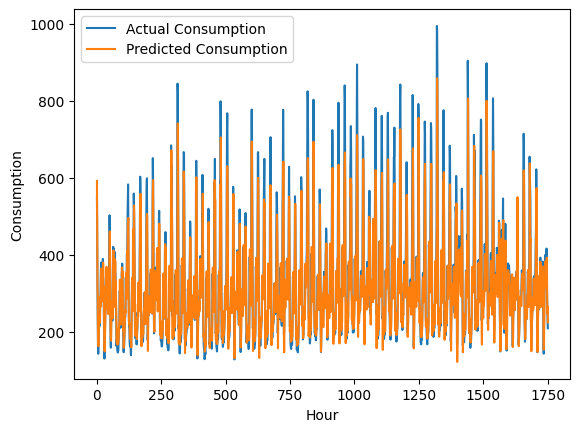

In [15]:
denormalized_y_test = scaler.inverse_transform(y_test.numpy())
denormalized_predicted = scaler.inverse_transform(predicted.numpy())
plt.plot(denormalized_y_test, label="Actual Consumption")
plt.plot(denormalized_predicted, label="Predicted Consumption")
plt.xlabel("Hour")
plt.ylabel("Consumption")
plt.legend()
plt.show()